<style>
.reveal { font-family: 'Segoe UI', system-ui, sans-serif; font-size: 1.05em; }
.reveal h2 { color: #0D2240; border-bottom: 2.5px solid #1A7A9A; padding-bottom: .3em; }
.reveal h3 { color: #1A7A9A; }
.reveal .slides section { text-align: left; }
.reveal pre { font-size: .75em; box-shadow: none; border-left: 3px solid #1A7A9A; }
.defn { background:#EAF6FA; border-left:4px solid #1A7A9A; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.nota { background:#FFF8E1; border-left:4px solid #C8961E; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.alerta { background:#FDE8E8; border-left:4px solid #C0392B; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
</style>

## Verificación y Validación de Modelos de Simulación
### T3.2 · Modelado de Sistemas bajo Incertidumbre
Universidad de los Andes · Ingeniería Industrial

## Agenda
1. Verificación vs. validación — la distinción fundamental
2. **Ejemplo 1:** verificación de M/M/1 con SimPy (traza, conservación, degenerada)
3. Validación estadística: IC y prueba t pareada
4. **Ejemplo 2:** validación de M/M/1 y detección de un bug (μ=4 vs μ=5)
5. Análisis de sensibilidad
6. **Ejemplo 3:** V&V completa de cola M/E₂/1 con sensibilidad

## Verificar vs. validar
<div class='defn'>
<strong>Verificación:</strong> ¿Construimos el modelo <em>correctamente</em>? (ingeniería de software)<br>
<strong>Validación:</strong> ¿Construimos el modelo <em>correcto</em>? (modelado)
</div>

| | Verificación | Validación |
|---|---|---|
| **Pregunta** | ¿El código implementa el modelo? | ¿El modelo representa el sistema? |
| **Técnicas** | Trazas, conservación, aserciones | IC vs. fórmulas, prueba t, comparación pareada |
| **Detecta** | Bugs en código | Supuestos incorrectos |

<div class='alerta'>
Un modelo puede estar <strong>verificado</strong> (sin bugs) pero <strong>no validado</strong> (supuestos incorrectos), y viceversa.
</div>

## Ejemplo 1 — Verificación M/M/1 con SimPy
<div class='defn'>
Cola M/M/1 con λ=3 cl/min, μ=5 cl/min (ρ=0.6).
Objetivo: verificar que la implementación en SimPy es correcta.
</div>

**Pruebas que realizaremos:**
1. Traza de los primeros 10 clientes (¿FIFO?, ¿N coherente?)
2. Conservación de entidades (llegadas = salidas + en sistema)
3. Prueba degenerada (λ → 0): la espera debe colapsar a 0
4. Tráfico extremo (ρ → 1): Wq debe crecer fuertemente

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st

def mm1_con_traza(lam, mu, T, seed=42, traza=False):
    """Simula M/M/1 hasta tiempo T. Si traza=True, imprime los primeros 10 clientes."""
    np.random.seed(seed)
    esperas, sistemas = [], []
    llegadas_tot, salidas_tot = 0, 0

    def cliente(env, srv, idx):
        nonlocal llegadas_tot, salidas_tot
        llegadas_tot += 1
        t_llegada = env.now
        with srv.request() as req:
            yield req
            espera = env.now - t_llegada
            esperas.append(espera)
            t_servicio = np.random.exponential(1/mu)
            if traza and idx <= 10:
                print(f'  C{idx:2d}: llega t={t_llegada:6.3f}  espera={espera:5.3f}  '
                      f'servicio={t_servicio:5.3f}  N={srv.count+len(srv.queue)}')
            yield env.timeout(t_servicio)
            sistemas.append(env.now - t_llegada)
            salidas_tot += 1

    def llegadas(env, srv):
        idx = 0
        while True:
            yield env.timeout(np.random.exponential(1/lam))
            idx += 1
            env.process(cliente(env, srv, idx))

    env = simpy.Environment()
    srv = simpy.Resource(env, capacity=1)
    env.process(llegadas(env, srv))
    env.run(until=T)

    return {'Wq': float(np.mean(esperas)) if esperas else 0.0,
            'W': float(np.mean(sistemas)) if sistemas else 0.0,
            'llegadas': llegadas_tot, 'salidas': salidas_tot,
            'en_sistema': llegadas_tot - salidas_tot,
            'esperas': esperas, 'sistemas': sistemas}

print('Función mm1_con_traza definida.')

Función mm1_con_traza definida.


In [2]:
lam, mu = 3, 5
print('═══ VERIFICACIÓN 1 · TRAZA DE LOS PRIMEROS 10 CLIENTES ═══')
_ = mm1_con_traza(lam, mu, T=20, traza=True)

═══ VERIFICACIÓN 1 · TRAZA DE LOS PRIMEROS 10 CLIENTES ═══
  C 1: llega t= 0.156  espera=0.000  servicio=0.263  N=1
  C 2: llega t= 1.160  espera=0.000  servicio=0.034  N=1
  C 3: llega t= 1.464  espera=0.000  servicio=0.012  N=1
  C 4: llega t= 1.521  espera=0.000  servicio=0.184  N=1
  C 5: llega t= 2.191  espera=0.000  servicio=0.004  N=1
  C 6: llega t= 2.601  espera=0.000  servicio=0.357  N=1
  C 7: llega t= 3.769  espera=0.000  servicio=0.040  N=1
  C 8: llega t= 3.849  espera=0.000  servicio=0.073  N=1
  C 9: llega t= 3.916  espera=0.005  servicio=0.113  N=1
  C10: llega t= 4.164  espera=0.000  servicio=0.189  N=1


In [3]:
print('═══ VERIFICACIÓN 2 · CONSERVACIÓN DE ENTIDADES (T=2000 min) ═══')
r = mm1_con_traza(lam, mu, T=2000)
print(f'Llegadas    = {r["llegadas"]}')
print(f'Salidas     = {r["salidas"]}')
print(f'En sistema  = {r["en_sistema"]}')
ok = r["llegadas"] == r["salidas"] + r["en_sistema"]
print(f'\n¿Llegadas = Salidas + En_sistema? {"Sí ✓" if ok else "NO ✗"}')

═══ VERIFICACIÓN 2 · CONSERVACIÓN DE ENTIDADES (T=2000 min) ═══
Llegadas    = 6132
Salidas     = 6132
En sistema  = 0

¿Llegadas = Salidas + En_sistema? Sí ✓


In [4]:
print('═══ VERIFICACIÓN 3 · PRUEBA DEGENERADA (λ → 0) ═══')
r_deg = mm1_con_traza(0.05, mu, T=200, seed=7)
print(f'Llegadas observadas: {r_deg["llegadas"]}')
print(f'Wq promedio        : {r_deg["Wq"]:.4f} min  (esperado ≈ 0)')
print(f'Sistema casi siempre vacío → la verificación pasa ✓' if r_deg["Wq"] < 0.05 else '⚠️ Wq mayor de lo esperado')

═══ VERIFICACIÓN 3 · PRUEBA DEGENERADA (λ → 0) ═══
Llegadas observadas: 11
Wq promedio        : 0.0000 min  (esperado ≈ 0)
Sistema casi siempre vacío → la verificación pasa ✓


In [5]:
print('═══ VERIFICACIÓN 4 · TRÁFICO EXTREMO (ρ → 1) ═══')
print(f'{"λ":>5} {"ρ":>6} {"Wq teórico":>12} {"Wq simulado":>14}')
print('-'*42)
for lam_v in [1, 2, 3, 4, 4.5]:
    rho = lam_v/mu
    Wq_teo = rho/(mu*(1-rho)) if rho < 1 else float('inf')
    Wq_sim = mm1_con_traza(lam_v, mu, T=4000, seed=11)['Wq']
    print(f'{lam_v:>5.1f} {rho:>6.2f} {Wq_teo:>12.3f} {Wq_sim:>14.3f}')
print('\n→ Wq crece monótonamente con ρ y se dispara cerca de 1: dirección correcta ✓')

═══ VERIFICACIÓN 4 · TRÁFICO EXTREMO (ρ → 1) ═══
    λ      ρ   Wq teórico    Wq simulado
------------------------------------------
  1.0   0.20        0.050          0.044
  2.0   0.40        0.133          0.117
  3.0   0.60        0.300          0.318
  4.0   0.80        0.800          0.875


  4.5   0.90        1.800          2.447

→ Wq crece monótonamente con ρ y se dispara cerca de 1: dirección correcta ✓


## Validación estadística
<div class='defn'>
Se ejecutan n réplicas independientes → Y₁, ..., Yₙ (i.i.d.). Se compara con un valor de referencia θ₀ (analítico):

$$IC_{95\%}(\theta) = \bar{Y}_n \pm t_{\alpha/2,\, n-1} \cdot \frac{S_n}{\sqrt{n}}$$

Si el IC contiene θ₀ → el modelo es <strong>consistente</strong> con la referencia.
</div>

**Decisión formal (prueba t):**
$$T = \frac{\bar{Y} - \theta_0}{S/\sqrt{n}} \sim t_{n-1}$$
Rechazamos H₀: θ = θ₀ si |T| > t_{α/2,\,n-1}.

**Fórmulas de referencia M/M/1:**
- $W_q = \rho / [\mu(1-\rho)]$
- $L_q = \rho^2 / (1-\rho)$

## Ejemplo 2 — Validación M/M/1 y detección de un bug
<div class='defn'>
Mismo sistema M/M/1 (λ=3, μ=5). Ejecutamos 30 réplicas para validar.
Luego mostramos qué pasa cuando el código tiene un <strong>bug sutil</strong>: μ=4 en vez de μ=5.
</div>

**Pregunta clave:** ¿la verificación habría detectado este error?
*Spoiler: no. Trazas y conservación pasan perfectamente con μ=4. Es la validación contra fórmulas la que lo detecta.*

In [6]:
def replicas_mm1(lam, mu, T, n_rep, seed_base=1000):
    """Ejecuta n_rep réplicas independientes y retorna el vector de Wq por réplica."""
    return np.array([mm1_con_traza(lam, mu, T, seed=seed_base+j)['Wq']
                     for j in range(n_rep)])

print('Función replicas_mm1 definida.')

Función replicas_mm1 definida.


In [7]:
lam, mu_correct = 3, 5
rho_correct = lam/mu_correct
Wq_ref = rho_correct / (mu_correct * (1-rho_correct))

n_rep = 30
Wq_ok = replicas_mm1(lam, mu_correct, T=2000, n_rep=n_rep, seed_base=1000)

mean_ok = Wq_ok.mean()
se_ok = Wq_ok.std(ddof=1)/np.sqrt(n_rep)
t_crit = st.t.ppf(0.975, n_rep-1)
ci_ok = (mean_ok - t_crit*se_ok, mean_ok + t_crit*se_ok)
T_ok = (mean_ok - Wq_ref) / se_ok
p_ok = 2 * (1 - st.t.cdf(abs(T_ok), n_rep-1))

print('═══ MODELO CORRECTO (μ=5) ═══')
print(f'Referencia analítica:  Wq = {Wq_ref:.3f} min')
print(f'Simulado (n={n_rep}):    Ȳ  = {mean_ok:.3f} min')
print(f'IC 95%:                [{ci_ok[0]:.3f}, {ci_ok[1]:.3f}]')
print(f'¿IC contiene {Wq_ref:.3f}? {"Sí ✓" if ci_ok[0] <= Wq_ref <= ci_ok[1] else "No ✗"}')
print(f'\nPrueba t: T = {T_ok:+.3f},  p-valor = {p_ok:.3f}')
print(f'Decisión: {"NO se rechaza H₀ → modelo VALIDADO ✓" if p_ok > 0.05 else "Se rechaza H₀ → discrepancia"}')

═══ MODELO CORRECTO (μ=5) ═══
Referencia analítica:  Wq = 0.300 min
Simulado (n=30):    Ȳ  = 0.304 min
IC 95%:                [0.295, 0.313]
¿IC contiene 0.300? Sí ✓

Prueba t: T = +0.942,  p-valor = 0.354
Decisión: NO se rechaza H₀ → modelo VALIDADO ✓


In [8]:
mu_bug = 4
Wq_bug = replicas_mm1(lam, mu_bug, T=2000, n_rep=n_rep, seed_base=2000)

mean_bug = Wq_bug.mean()
se_bug = Wq_bug.std(ddof=1)/np.sqrt(n_rep)
ci_bug = (mean_bug - t_crit*se_bug, mean_bug + t_crit*se_bug)
T_bug = (mean_bug - Wq_ref) / se_bug
p_bug = 2 * (1 - st.t.cdf(abs(T_bug), n_rep-1))

print('═══ MODELO CON BUG (μ=4 en vez de 5) ═══')
print(f'Referencia esperada (μ=5):  Wq = {Wq_ref:.3f} min')
print(f'Simulado (n={n_rep}):         Ȳ  = {mean_bug:.3f} min')
print(f'IC 95%:                     [{ci_bug[0]:.3f}, {ci_bug[1]:.3f}]')
print(f'¿IC contiene {Wq_ref:.3f}? {"Sí" if ci_bug[0] <= Wq_ref <= ci_bug[1] else "NO ✗ → BUG DETECTADO"}')
print(f'\nPrueba t: T = {T_bug:+.3f},  p-valor = {p_bug:.3e}')
print(f'Decisión: {"Se rechaza H₀ → MODELO NO VALIDADO" if p_bug < 0.05 else "no se rechaza"}')
print(f'\n💡 ρ̂ ≈ {lam/mu_bug:.2f} = {lam}/{mu_bug} → el desbordamiento apunta a μ = {mu_bug}')

═══ MODELO CON BUG (μ=4 en vez de 5) ═══
Referencia esperada (μ=5):  Wq = 0.300 min
Simulado (n=30):         Ȳ  = 0.774 min
IC 95%:                     [0.741, 0.807]
¿IC contiene 0.300? NO ✗ → BUG DETECTADO

Prueba t: T = +29.448,  p-valor = 0.000e+00
Decisión: Se rechaza H₀ → MODELO NO VALIDADO

💡 ρ̂ ≈ 0.75 = 3/4 → el desbordamiento apunta a μ = 4


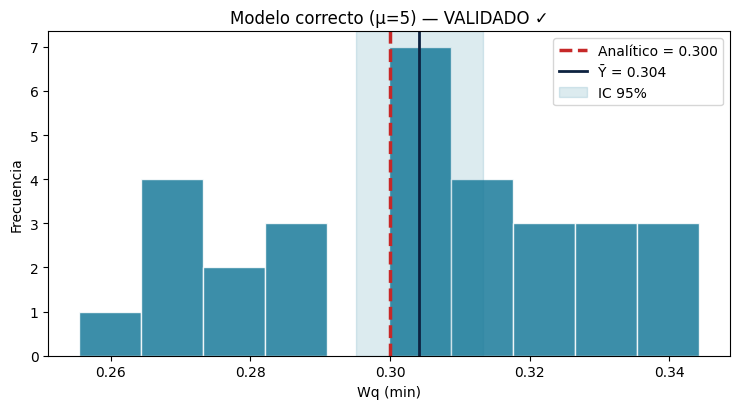

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(Wq_ok, bins=10, color='#1A7A9A', edgecolor='white', alpha=0.85)
ax.axvline(Wq_ref, color='#C62828', lw=2.5, ls='--', label=f'Analítico = {Wq_ref:.3f}')
ax.axvline(mean_ok, color='#0D2240', lw=2, label=f'Ȳ = {mean_ok:.3f}')
ax.axvspan(ci_ok[0], ci_ok[1], alpha=0.15, color='#1A7A9A', label='IC 95%')
ax.set_xlabel('Wq (min)'); ax.set_ylabel('Frecuencia')
ax.set_title('Modelo correcto (μ=5) — VALIDADO ✓')
ax.legend()
plt.tight_layout(); plt.show()

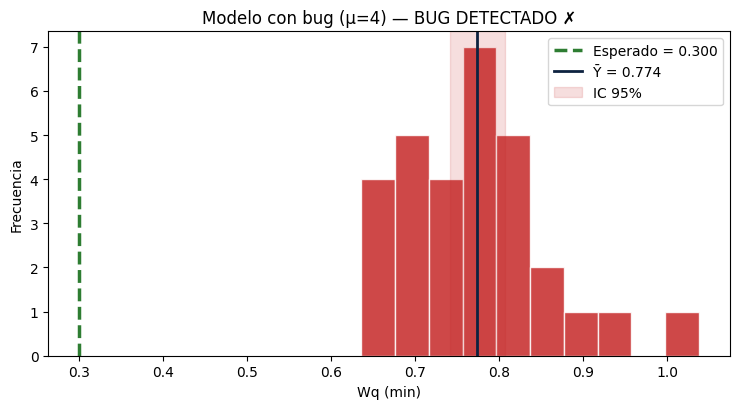

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(Wq_bug, bins=10, color='#C62828', edgecolor='white', alpha=0.85)
ax.axvline(Wq_ref, color='#2E7D32', lw=2.5, ls='--', label=f'Esperado = {Wq_ref:.3f}')
ax.axvline(mean_bug, color='#0D2240', lw=2, label=f'Ȳ = {mean_bug:.3f}')
ax.axvspan(ci_bug[0], ci_bug[1], alpha=0.15, color='#C62828', label='IC 95%')
ax.set_xlabel('Wq (min)'); ax.set_ylabel('Frecuencia')
ax.set_title('Modelo con bug (μ=4) — BUG DETECTADO ✗')
ax.legend()
plt.tight_layout(); plt.show()

## Análisis de sensibilidad
<div class='defn'>
Verificar que el modelo responde en la <strong>dirección correcta</strong> y con <strong>magnitud razonable</strong> ante cambios en parámetros.
</div>

**Procedimiento:**
1. Variar cada parámetro ±10–20%
2. Verificar la dirección (si λ↑ → Wq↑)
3. Verificar la magnitud (no-linealidad cerca de ρ→1)
4. Si la dirección es incorrecta → **error en el modelo**

## Ejemplo 3 — V&V completa: cola M/E₂/1
<div class='defn'>
Celda de manufactura: llegadas Poisson (λ=4 pzas/h), servicio Erlang-2 (E[S]=0.2 h, CV=0.71). ρ=0.8.
Proceso completo: validación contra Pollaczek-Khinchine + análisis de sensibilidad.
</div>

**Referencia P-K:**
$$W_q = \frac{\lambda E[S^2]}{2(1-\rho)} = \frac{4 \times 0.06}{2 \times 0.2} = 0.60 \text{ h}$$

In [11]:
def me2_1(lam, mu_fase, T, seed=42):
    """Simula M/E₂/1: servicio = suma de 2 exponenciales con tasa mu_fase."""
    np.random.seed(seed)
    esperas = []

    def cliente(env, srv):
        t_llegada = env.now
        with srv.request() as req:
            yield req
            esperas.append(env.now - t_llegada)
            yield env.timeout(np.random.exponential(1/mu_fase))
            yield env.timeout(np.random.exponential(1/mu_fase))

    def llegadas(env, srv):
        while True:
            yield env.timeout(np.random.exponential(1/lam))
            env.process(cliente(env, srv))

    env = simpy.Environment()
    srv = simpy.Resource(env, capacity=1)
    env.process(llegadas(env, srv))
    env.run(until=T)
    return float(np.mean(esperas)) if esperas else 0.0

print('Función me2_1 definida.')

Función me2_1 definida.


In [12]:
lam_m, mu_f = 4.0, 10.0          # pzas/h, fases/h
ES = 2/mu_f                       # 0.20 h
ES2 = 2/mu_f**2 + ES**2           # 0.06 h²
rho_m = lam_m * ES                # 0.80
Wq_PK = lam_m * ES2 / (2*(1-rho_m))

n_rep = 50
Wq_reps = np.array([me2_1(lam_m, mu_f, T=2000, seed=2000+j) for j in range(n_rep)])
mean_m = Wq_reps.mean()
se_m = Wq_reps.std(ddof=1)/np.sqrt(n_rep)
t_c = st.t.ppf(0.975, n_rep-1)
ci_m = (mean_m - t_c*se_m, mean_m + t_c*se_m)
T_m = (mean_m - Wq_PK) / se_m
p_m = 2 * (1 - st.t.cdf(abs(T_m), n_rep-1))

print('═══ VALIDACIÓN M/E₂/1 vs FÓRMULA P-K ═══')
print(f'P-K analítico:  Wq = {Wq_PK:.3f} h')
print(f'Simulado n={n_rep}: Ȳ  = {mean_m:.3f} h')
print(f'IC 95%:         [{ci_m[0]:.3f}, {ci_m[1]:.3f}]')
print(f'¿IC contiene {Wq_PK:.3f}? {"Sí ✓" if ci_m[0] <= Wq_PK <= ci_m[1] else "No ✗"}')
print(f'\nPrueba t:  T = {T_m:+.3f},  p-valor = {p_m:.3f}')
print(f'Error relativo: {abs(mean_m-Wq_PK)/Wq_PK*100:.1f}%')
print(f'Decisión: {"modelo VALIDADO ✓" if p_m > 0.05 else "discrepancia significativa"}')

═══ VALIDACIÓN M/E₂/1 vs FÓRMULA P-K ═══
P-K analítico:  Wq = 0.600 h
Simulado n=50: Ȳ  = 0.603 h
IC 95%:         [0.584, 0.621]
¿IC contiene 0.600? Sí ✓

Prueba t:  T = +0.290,  p-valor = 0.773
Error relativo: 0.4%
Decisión: modelo VALIDADO ✓


In [13]:
print('═══ SENSIBILIDAD ANTE λ (±20%) ═══')
print(f'{"λ":>6} {"ρ":>6} {"Wq P-K":>10} {"Wq sim":>10} {"|Δrel|":>8}')
print('-'*46)
sens = []
for factor in [0.8, 0.9, 1.0, 1.1, 1.2]:
    lam_v = lam_m * factor
    rho_v = lam_v * ES
    Wq_v = lam_v * ES2 / (2*(1-rho_v))
    Wq_sim_v = np.mean([me2_1(lam_v, mu_f, T=1500, seed=3000+j) for j in range(20)])
    err = abs(Wq_sim_v - Wq_v) / Wq_v * 100
    sens.append((lam_v, rho_v, Wq_v, Wq_sim_v))
    flag = ' (base)' if factor == 1.0 else ''
    print(f'{lam_v:>6.2f} {rho_v:>6.2f} {Wq_v:>10.3f} {Wq_sim_v:>10.3f} {err:>7.1f}%{flag}')

print('\n→ Wq simulado crece monótonamente con λ y reproduce la no-linealidad de la P-K.')

═══ SENSIBILIDAD ANTE λ (±20%) ═══
     λ      ρ     Wq P-K     Wq sim   |Δrel|
----------------------------------------------


  3.20   0.64      0.267      0.260     2.7%


  3.60   0.72      0.386      0.378     2.1%


  4.00   0.80      0.600      0.584     2.6% (base)


  4.40   0.88      1.100      0.996     9.5%


  4.80   0.96      3.600      3.167    12.0%

→ Wq simulado crece monótonamente con λ y reproduce la no-linealidad de la P-K.


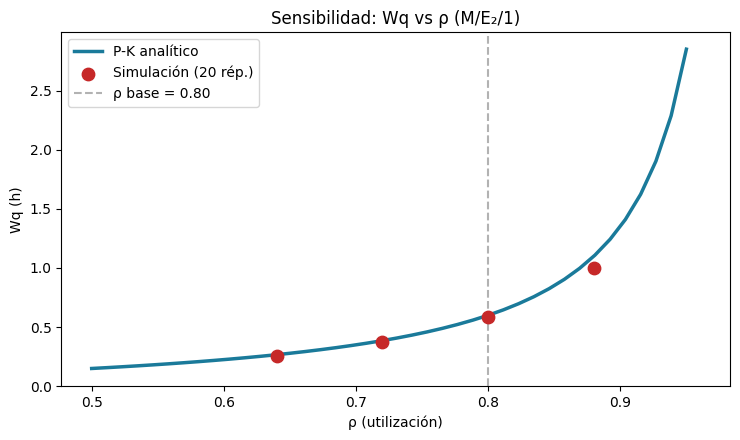

In [14]:
rho_range = np.linspace(0.5, 0.95, 40)
Wq_curve = [(r/ES)*ES2/(2*(1-r)) for r in rho_range]
rho_pts = np.array([s[1] for s in sens])
Wq_sim_pts = np.array([s[3] for s in sens])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(rho_range, Wq_curve, color='#1A7A9A', lw=2.5, label='P-K analítico')
ax.scatter(rho_pts, Wq_sim_pts, color='#C62828', s=80, zorder=5, label='Simulación (20 rép.)')
ax.axvline(0.80, ls='--', color='gray', alpha=0.6, label='ρ base = 0.80')
ax.set_xlabel('ρ (utilización)'); ax.set_ylabel('Wq (h)')
ax.set_title('Sensibilidad: Wq vs ρ (M/E₂/1)')
ax.legend(); ax.set_ylim(0, max(Wq_curve)*1.05)
plt.tight_layout(); plt.show()

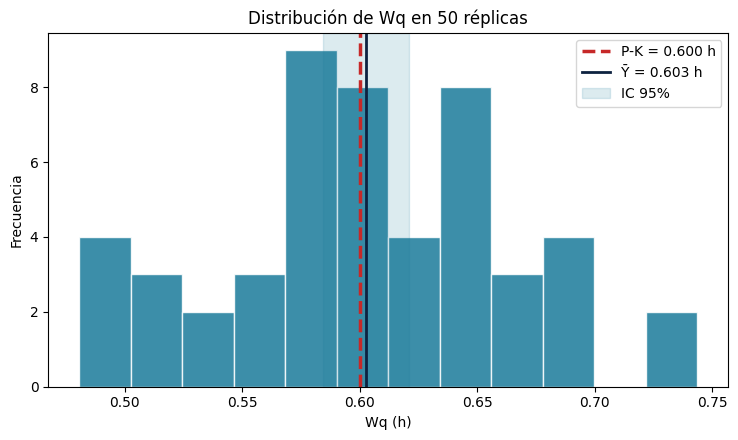

✓ Modelo verificado y validado. Listo para análisis avanzados.


In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(Wq_reps, bins=12, color='#1A7A9A', edgecolor='white', alpha=0.85)
ax.axvline(Wq_PK, color='#C62828', lw=2.5, ls='--', label=f'P-K = {Wq_PK:.3f} h')
ax.axvline(mean_m, color='#0D2240', lw=2, label=f'Ȳ = {mean_m:.3f} h')
ax.axvspan(ci_m[0], ci_m[1], alpha=0.15, color='#1A7A9A', label='IC 95%')
ax.set_xlabel('Wq (h)'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Wq en 50 réplicas')
ax.legend()
plt.tight_layout(); plt.show()
print('✓ Modelo verificado y validado. Listo para análisis avanzados.')

## Conclusiones

- La **verificación** (trazas, conservación, degeneradas) detecta bugs de lógica.
- La **validación** (IC + prueba t vs. fórmulas) detecta errores de parametrización que la verificación no encuentra.
- La **prueba t** acompaña al IC: cuantifica la evidencia con un p-valor.
- El **análisis de sensibilidad** confirma que el modelo responde coherentemente y revela la no-linealidad cerca de ρ→1.
- Ambos procesos son **necesarios e insuficientes** por separado.
- La fórmula **P-K** (M/G/1) es la herramienta ideal de validación: verifica el promedio y, si coincide, confiamos en percentiles y otras métricas simuladas.

**Próximo tema:** T3.3 — análisis de salida: simulaciones terminales.